# Rerouted Barrels: Tanker Traffic Through Hormuz, Bab el-Mandeb and Suez, 2023–2026

**Question.** How did oil tanker traffic shift between the four main Gulf–Europe/Asia chokepoints after the Houthi attacks (from November 2023), the Hormuz crisis (from 28 February 2026) and the Houthi blockade of Saudi shipping (from 20 July 2026)?

**Data.** IMF PortWatch, *Daily Chokepoint Transit Calls and Trade Volume Estimates* (downloaded 24 September 2026; data to 20 September 2026). The raw file is not included here; download it from PortWatch and save it as `Daily_Chokepoints_Data.csv` next to this notebook.

**Approach.** Compare average daily tanker transits and tanker capacity in three windows (2024, H1 2026, 20 Jul–20 Sep 2026) with a pre-crisis baseline: the average day from 1 January to 15 November 2023, i.e. before the *Galaxy Leader* seizure on 19 November 2023.

*Code written with AI assistance (Claude). Research question, data choices, checks against sources and interpretation are my own.*

## 1. Load the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Daily_Chokepoints_Data.csv")
df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None).dt.normalize()
print(df.shape)
print(sorted(df["portname"].unique()))

(78960, 21)
['Bab el-Mandeb Strait', 'Balabac Strait', 'Bering Strait', 'Bohai Strait', 'Bosporus Strait', 'Cape of Good Hope', 'Dover Strait', 'Gibraltar Strait', 'Kerch Strait', 'Korea Strait', 'Lombok Strait', 'Luzon Strait', 'Magellan Strait', 'Makassar Strait', 'Malacca Strait', 'Mindoro Strait', 'Mona Passage', 'Ombai Strait', 'Oresund Strait', 'Panama Canal', 'Strait of Hormuz', 'Suez Canal', 'Sunda Strait', 'Taiwan Strait', 'Torres Strait', 'Tsugaru Strait', 'Windward Passage', 'Yucatan Channel']


## 2. Keep the four oil chokepoints, from 1 January 2023
Each chokepoint has one row per day; the check below confirms there are no gaps or duplicates.

In [2]:
CHOKEPOINTS = {
    "Strait of Hormuz":     "Strait of Hormuz",
    "Bab el-Mandeb Strait": "Bab el-Mandeb",
    "Suez Canal":           "Suez Canal",
    "Cape of Good Hope":    "Cape of Good Hope",
}
data = df[df["portname"].isin(CHOKEPOINTS) & (df["date"] >= "2023-01-01")].copy()
data["chokepoint"] = data["portname"].map(CHOKEPOINTS)

check = data.groupby("chokepoint")["date"].agg(["min", "max", "count", "nunique"])
print(check)
LAST_DATE = data["date"].max()

                         min        max  count  nunique
chokepoint                                             
Bab el-Mandeb     2023-01-01 2026-09-20   1359     1359
Cape of Good Hope 2023-01-01 2026-09-20   1359     1359
Strait of Hormuz  2023-01-01 2026-09-20   1359     1359
Suez Canal        2023-01-01 2026-09-20   1359     1359


## 3. Average daily traffic by window, and % change vs the 2023 baseline
Tanker **capacity** is used for the headline numbers because it is closer to barrels than a ship count. Containerships are included for comparison.

In [3]:
WINDOWS = {
    "Baseline 2023":      ("2023-01-01", "2023-11-15"),
    "2024":               ("2024-01-01", "2024-12-31"),
    "H1 2026":            ("2026-01-01", "2026-06-30"),
    "Post-blockade 2026": ("2026-07-20", str(LAST_DATE.date())),
}
MEASURES = {"Tankers": "n_tanker", "Containerships": "n_container", "Tanker capacity": "capacity_tanker"}

rows = []
for cp in CHOKEPOINTS.values():
    sub = data[data["chokepoint"] == cp]
    for name, col in MEASURES.items():
        row = {"chokepoint": cp, "measure": name}
        for w, (start, end) in WINDOWS.items():
            row[w] = sub[sub["date"].between(start, end)][col].mean()
        rows.append(row)
avg = pd.DataFrame(rows).set_index(["chokepoint", "measure"])

pct = pd.DataFrame(index=avg.index)
for w in list(WINDOWS)[1:]:
    pct[w + " vs baseline (%)"] = ((avg[w] / avg["Baseline 2023"] - 1) * 100).round(0) + 0.0  # + 0.0 turns -0 into 0

avg.round(2).to_csv("results_daily_average.csv")
pct.to_csv("results_pct_change.csv")
pct

2024 vs baseline (%)  \
chokepoint        measure                                 
Strait of Hormuz  Tankers                          -7.0   
                  Containerships                    0.0   
                  Tanker capacity                 -10.0   
Bab el-Mandeb     Tankers                         -55.0   
                  Containerships                  -72.0   
                  Tanker capacity                 -56.0   
Suez Canal        Tankers                         -44.0   
                  Containerships                  -55.0   
                  Tanker capacity                 -51.0   
Cape of Good Hope Tankers                         108.0   
                  Containerships                  223.0   
                  Tanker capacity                  66.0   

                                   H1 2026 vs baseline (%)  \
chokepoint        measure                                    
Strait of Hormuz  Tankers                            -76.0   
                  Containerships                     -74.0   
                  Tanker capacity                    -77.0   
Bab el-Mandeb     Tankers                            -47.0   
                  Containerships                     -70.0   
                  Tanker capacity                    -46.0   
Suez Canal        Tankers                            -36.0   
                  Containerships                     -56.0   
                  Tanker capacity                    -44.0   
Cape of Good Hope Tankers                            106.0   
                  Containerships                     247.0   
                  Tanker capacity                     51.0   

                                   Post-blockade 2026 vs baseline (%)  
chokepoint        measure                                              
Strait of Hormuz  Tankers                                       -98.0  
                  Containerships                                -98.0  
                  Tanker capacity                               -99.0  
Bab el-Mandeb     Tankers                                       -68.0  
                  Containerships                                -74.0  
                  Tanker capacity                               -71.0  
Suez Canal        Tankers                                       -37.0  
                  Containerships                                -49.0  
                  Tanker capacity                               -47.0  
Cape of Good Hope Tankers                                       106.0  
                  Containerships                                203.0  
                  Tanker capacity                                51.0

## 4. Chart 1: weekly tanker transits with key events
Only complete 7-day weeks are plotted, so a partial final week does not appear as a false drop.

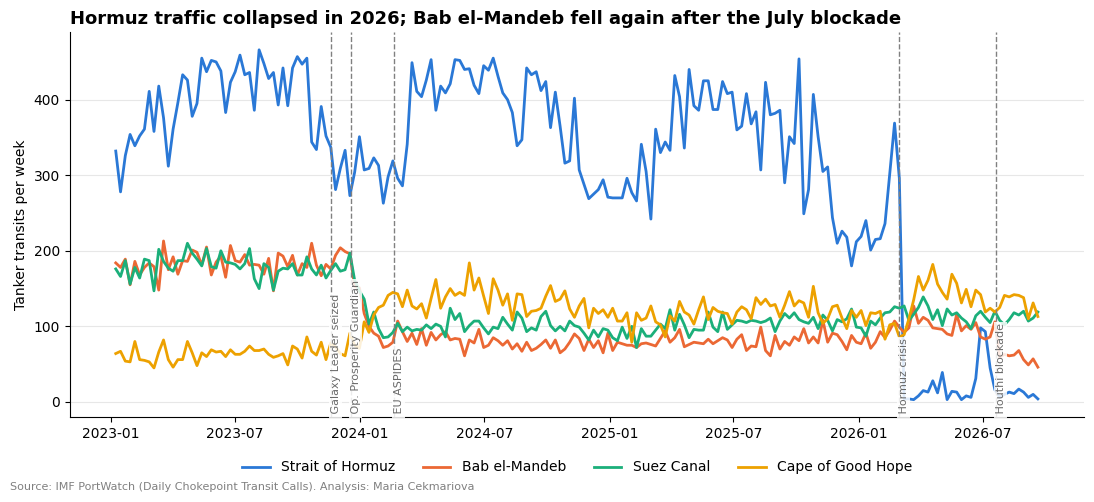

In [4]:
EVENTS = {
    "2023-11-19": "Galaxy Leader seized",
    "2023-12-18": "Op. Prosperity Guardian",
    "2024-02-19": "EU ASPIDES",
    "2026-02-28": "Hormuz crisis",
    "2026-07-20": "Houthi blockade",
}
COLORS = {"Strait of Hormuz": "#2a78d6", "Bab el-Mandeb": "#eb6834",
          "Suez Canal": "#1baf7a", "Cape of Good Hope": "#eda100"}

g = data.set_index("date").groupby("chokepoint")["n_tanker"].resample("W-SUN")
weekly = g.sum().unstack(0)
weekly = weekly[g.count().unstack(0).min(axis=1) == 7]

fig, ax = plt.subplots(figsize=(11, 5))
for cp, c in COLORS.items():
    ax.plot(weekly.index, weekly[cp], lw=2, color=c, label=cp)
for d, text in EVENTS.items():
    ax.axvline(pd.Timestamp(d), color="grey", lw=1, ls="--")
    ax.text(pd.Timestamp(d), ax.get_ylim()[0], " " + text, rotation=90, va="bottom", fontsize=8,
            color="dimgrey", bbox=dict(facecolor="white", edgecolor="none", pad=1, alpha=0.85))
ax.set_title("Hormuz traffic collapsed in 2026; Bab el-Mandeb fell again after the July blockade",
             loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Tanker transits per week")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.3)
fig.text(0.01, 0.01, "Source: IMF PortWatch (Daily Chokepoint Transit Calls). Analysis: Maria Cekmariova",
         fontsize=8, color="grey")
plt.tight_layout(); plt.savefig("chart1_weekly_tankers.png", dpi=200, bbox_inches="tight"); plt.show()

## 5. Chart 2: tanker capacity vs 2023 baseline
Note: H1 2026 includes January–February, before the war began on 28 February.

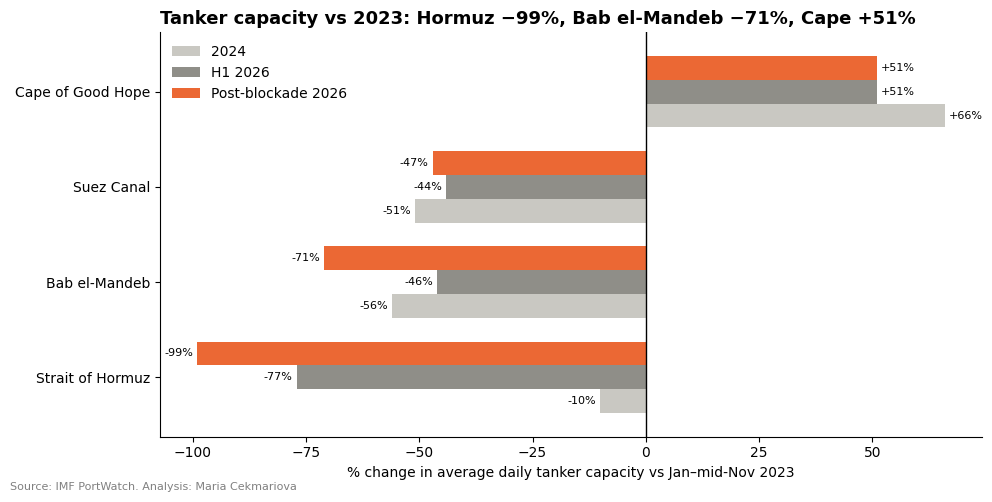

In [5]:
chart2 = pct.xs("Tanker capacity", level="measure")
chart2.columns = [c.replace(" vs baseline (%)", "") for c in chart2.columns]

ax = chart2.plot(kind="barh", figsize=(10, 5), color=["#c9c8c2", "#8f8e88", "#eb6834"], width=0.75)
ax.axvline(0, color="black", lw=1)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%+.0f%%", fontsize=8, padding=3)
ax.set_title("Tanker capacity vs 2023: Hormuz −99%, Bab el-Mandeb −71%, Cape +51%",
             loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel("% change in average daily tanker capacity vs Jan–mid-Nov 2023"); ax.set_ylabel("")
ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False)
plt.gcf().text(0.01, 0.01, "Source: IMF PortWatch. Analysis: Maria Cekmariova", fontsize=8, color="grey")
plt.tight_layout(); plt.savefig("chart2_pct_change.png", dpi=200, bbox_inches="tight"); plt.show()

## 6. Chart 3: tankers vs containerships at Bab el-Mandeb
Both series are indexed to their own 2023 baseline (100 = normal) so they can be compared.

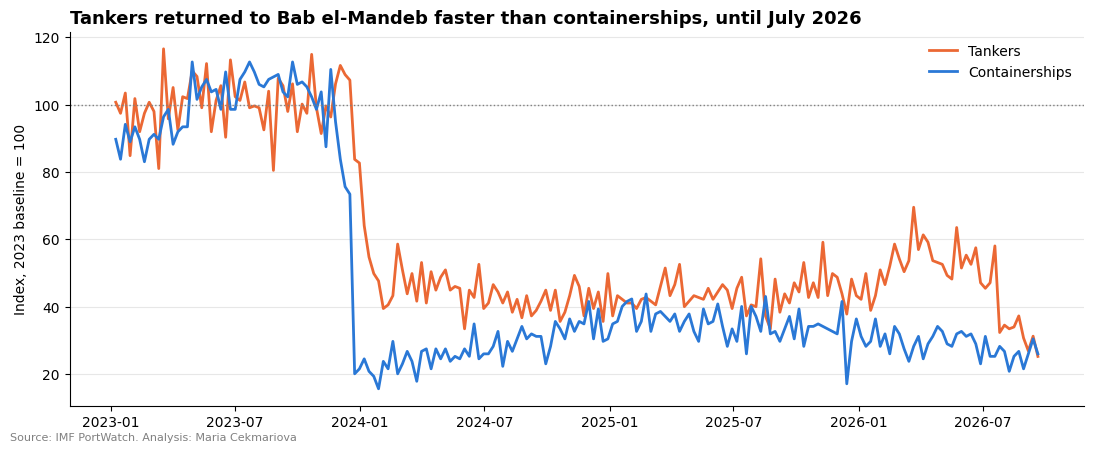

In [6]:
bab = data[data["chokepoint"] == "Bab el-Mandeb"].set_index("date")
r = bab[["n_tanker", "n_container"]].resample("W-SUN")
w = r.sum()[r.size() == 7]
idx = w / w.loc["2023-01-01":"2023-11-15"].mean() * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(idx.index, idx["n_tanker"], lw=2, color="#eb6834", label="Tankers")
ax.plot(idx.index, idx["n_container"], lw=2, color="#2a78d6", label="Containerships")
ax.axhline(100, color="grey", lw=1, ls=":")
ax.set_title("Tankers returned to Bab el-Mandeb faster than containerships, until July 2026",
             loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Index, 2023 baseline = 100")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.3)
fig.text(0.01, 0.01, "Source: IMF PortWatch. Analysis: Maria Cekmariova", fontsize=8, color="grey")
plt.tight_layout(); plt.savefig("chart3_tankers_vs_containers.png", dpi=200, bbox_inches="tight"); plt.show()

## 7. Limitations
- PortWatch counts are based on AIS signals; ships that switch transponders off in conflict zones are undercounted, so Hormuz figures are *recorded* transits.
- Transit counts and capacity are not barrels actually carried.
- The post-blockade window is 63 days (20 July–20 September 2026) and PortWatch figures may be revised.